In [ ]:
## For Figure 5 and Table S2 in benchmarking paper
## Plot seasonal cycle of GPP, LH, and residuals at flux tower sites compared to FATES
## use precip at each site to find average dry season and indicate on figure with light tan bar

In [1]:
import numpy as np
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import pandas as pd
from scipy.ndimage import uniform_filter1d


ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
### Read in FATES file
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
fates_file=fates_tag+'.elm.h2.cat.nc'
fates = xr.open_dataset(fates_path+fates_file)

In [3]:
## Get FATES GPP at each site

## Paracou, French Guiana
par_lat=5.2787
par_lon=360.-52.9248
par_dt=-3 ## time in CSV file is local time, so we don't need to apply this to observed data

### Tapajos (TAP) - Brazil - UTC-3
tap_lat=-3.3  
tap_lon=305.0
tap_dt=-4 # solar time is UTC - 3.5
tap_dt2=-3 # flux tower data timestamp is beginning of measurement interval

## Tanguro - Brazil
tan_lat = -13.08 
tan_lon = 307.59
tan_dt = -4 # GMT-4 -- for FATES simulations
tan_dt2 = 0 ## flux tower data is in local time

## K34 -- Brazil
k34_lat = -2.6091
k34_lon = 360.-60.2093
k34_dt = -4

In [4]:
import cftime

def cftime_to_doy(cf_datetime_array):
  """
  Converts an array (or list) of cftime.DatetimeNoLeap() objects to an array of DOY values.

  Args:
    cf_datetime_array: An iterable (e.g., list, array) of cftime.DatetimeNoLeap() objects.

  Returns:
    A list of integers representing the day of year (1-365) for each input datetime object.
    Returns an empty list if the input is empty or contains non-cftime.DatetimeNoLeap objects.
  """
  doy_array = []
  for cf_datetime in cf_datetime_array:
    if isinstance(cf_datetime, cftime.DatetimeNoLeap):
      doy_array.append(cf_datetime.dayofyr)
    else:
      print(f"Warning: Skipping non-cftime.DatetimeNoLeap object: {cf_datetime}")
  return doy_array


In [5]:
fates_doy=cftime_to_doy(fates.time.values)

In [6]:
par_lat_abs_diff = np.abs(fates.lat.data - par_lat)
par_lat_ind = np.argmin(par_lat_abs_diff)
par_lon_abs_diff = np.abs(fates.lon.data - par_lon)
par_lon_ind = np.argmin(par_lon_abs_diff)

tap_lat_abs_diff = np.abs(fates.lat.data - tap_lat)
tap_lat_ind = np.argmin(tap_lat_abs_diff)
tap_lon_abs_diff = np.abs(fates.lon.data - tap_lon)
tap_lon_ind = np.argmin(tap_lon_abs_diff)

tan_lat_abs_diff = np.abs(fates.lat.data - tan_lat)
tan_lat_ind = np.argmin(tan_lat_abs_diff)
tan_lon_abs_diff = np.abs(fates.lon.data - tan_lon)
tan_lon_ind = np.argmin(tan_lon_abs_diff)

k34_lat_abs_diff = np.abs(fates.lat.data - k34_lat)
k34_lat_ind = np.argmin(k34_lat_abs_diff)
k34_lon_abs_diff = np.abs(fates.lon.data - k34_lon)
k34_lon_ind = np.argmin(k34_lon_abs_diff)

In [7]:
## For calculating dry season from FATES 
file0=fates_tag+'.elm.h0.cat.nc' # should be daily output
d0 = xr.open_dataset(fates_path+file0)

In [8]:
# d0.RAIN in mm/s
# get monthly average rainfall
fates_avg_rain = d0.RAIN.groupby('time.month').mean(dim='time')
# multiply by seconds per month to get total monthly rainfall in mm
sec_per_month=3.156e+7/12.
gswp_rain_par=sec_per_month*fates_avg_rain.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data
gswp_rain_tap=sec_per_month*fates_avg_rain.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data
gswp_rain_k34=sec_per_month*fates_avg_rain.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data
gswp_rain_tan=sec_per_month*fates_avg_rain.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data

In [9]:
## calculate yearly cycle for GPP and LH at each site as simulated by FATES
fates_days=np.unique(fates_doy)

## Paracou
fates_par_avg_GPP=np.zeros(len(fates_days))
fates_par_std_GPP=np.zeros(len(fates_days))
fates_par_avg_LH=np.zeros(len(fates_days))
fates_par_std_LH=np.zeros(len(fates_days))

## Tapajos
fates_tap_avg_GPP=np.zeros(len(fates_days))
fates_tap_std_GPP=np.zeros(len(fates_days))
fates_tap_avg_LH=np.zeros(len(fates_days))
fates_tap_std_LH=np.zeros(len(fates_days))

## Tanguro
fates_tan_avg_GPP=np.zeros(len(fates_days))
fates_tan_std_GPP=np.zeros(len(fates_days))
fates_tan_avg_LH=np.zeros(len(fates_days))
fates_tan_std_LH=np.zeros(len(fates_days))

## K34
fates_k34_avg_GPP=np.zeros(len(fates_days))
fates_k34_std_GPP=np.zeros(len(fates_days))
fates_k34_avg_LH=np.zeros(len(fates_days))
fates_k34_std_LH=np.zeros(len(fates_days))

for i in range(len(fates_days)):
    ind=np.where(fates_doy == fates_days[i])
    fates_par_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_par_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_tap_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tap_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tan_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_tan_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_k34_avg_GPP[i]=np.nanmean((fates.FATES_GPP.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_k34_std_GPP[i]=np.nanstd((fates.FATES_GPP.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_par_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_par_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data)[ind[0]]) 
    fates_tap_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tap_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data)[ind[0]]) 
    fates_tan_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_tan_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data)[ind[0]]) 
    fates_k34_avg_LH[i]=np.nanmean((fates.EFLX_LH_TOT.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 
    fates_k34_std_LH[i]=np.nanstd((fates.EFLX_LH_TOT.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data)[ind[0]]) 


In [10]:
## Get flux tower data

In [11]:
## read in Paracou flux tower data
# Note: ICOS dataset is 2017-2024
# we want 2004-2014 to overlap with FATES forcing (1990-2014)
flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
par_file='Guyaflux/data.csv'


In [12]:
par_df = pd.read_csv(flx_path+par_file,sep=',')

In [13]:
par_df.columns.to_list()

['TimeB',
 'Year',
 'Month',
 'Julian Day',
 'Hour/min',
 'time',
 'Temp(55)',
 'Hr(55)',
 'Rg',
 'Tsoil(CS615)',
 'SWC615',
 'Patm',
 'Wind-D',
 'Wind-S',
 'Rain',
 'VPD55',
 'Rn(55m)',
 'ETP',
 'ETP New CNR4',
 'SWC (-10 cm)',
 'SWC (-20 cm)',
 'SWC (-80 cm)',
 'SWC (-160 cm)',
 'SWC (-260 cm)',
 'LE(O)corr',
 'H',
 'Ustar',
 'NEE',
 'NEE_f',
 'Reco-R',
 'GPP-R',
 'Reco-L',
 'GPP-L',
 'Fc',
 'Storage',
 'LE_f',
 'H_f',
 'CNR4_temp',
 'CNR4_SW_up',
 'CNR4_SW_dn',
 'CNR4_LW_up',
 'CNR4_LW_dn',
 'CNR4_Rn',
 'VWC_10cm',
 'VWC_20cm',
 'VWC_80cm',
 'VWC_140cm',
 'VWC_190cm',
 'T_10cm',
 'T_20cm',
 'T_80cm',
 'T_140cm',
 'T_190cm',
 'Rain précis']

In [14]:
par_df['GPP-R'].isna().any()

True

In [15]:
years=np.unique(par_df['Year'].values)

In [16]:
## 1. Filter out the leap days (Feb 29)
is_leap_year = (par_df['Year'] % 4 == 0)
is_leap_day = (par_df['Julian Day'] == 60)

# Filter out rows where both conditions are true
par_df_subset = par_df[~(is_leap_year & is_leap_day)].copy()

## 2. SHIFT THE REMAINING DAYS IN LEAP YEARS
# Extract the raw years and days from the cleaned dataframe
par_year = par_df_subset['Year'].values
raw_par_jd = par_df_subset['Julian Day'].values

# Identify rows that are leap years AND take place after Feb 28th (raw_par_jd > 60)
is_leap_year_clean = (par_year % 4 == 0)
post_feb28 = (raw_par_jd > 60)

# Shift days after Feb 28 backward by 1 day in leap years
par_jd_all = np.where(is_leap_year_clean & post_feb28, raw_par_jd - 1, raw_par_jd)

## 3. Get the final unique 1-365 day list for your loop
par_jd = np.unique(par_jd_all)


In [17]:
par_gppR=par_df_subset['GPP-R'].values # Gross primary productivity-Reichstein,µmolm-2 s-1
par_gppL=par_df_subset['GPP-L'].values # Gross primary productivity-Lasslop,µmolm-2 s-1

In [18]:
par_gppR

array([-0.5 , -0.5 , -1.95, ...,  1.78,  1.74,  1.85])

In [19]:
np.amin(par_gppL)

nan

In [20]:
# check for missing values -- GPP is gapfilled so there shouldn't be any
par_df_subset['GPP-R'].isna().any()

True

In [21]:
par_df_subset['GPP-L'].isna().any()

True

In [22]:
par_precip=par_df_subset['Rain'].values # Rain,Rainfall,mm,,

In [23]:
par_LH=par_df_subset['LE_f'].values # Latent heat (gapfilled),W m-2

In [24]:
## calculate average yearly cycle of GPP and LH at Paracou

par_avg_GPP_R=np.zeros(len(par_jd))
par_std_GPP_R=np.zeros(len(par_jd))

par_avg_GPP_L=np.zeros(len(par_jd))
par_std_GPP_L=np.zeros(len(par_jd))

par_avg_LH=np.zeros(len(par_jd))
par_std_LH=np.zeros(len(par_jd))

par_rain=np.zeros(len(par_jd))

for i in range(len(par_jd)):
    ind=np.where(par_jd_all == par_jd[i])
    par_avg_GPP_R[i]=np.nanmean(par_gppR[ind[0]]) 
    par_std_GPP_R[i]=np.nanstd(par_gppR[ind[0]]) 
    par_avg_GPP_L[i]=np.nanmean(par_gppL[ind[0]]) 
    par_std_GPP_L[i]=np.nanstd(par_gppL[ind[0]]) 
    par_avg_LH[i]=np.nanmean(par_LH[ind[0]]) 
    par_std_LH[i]=np.nanstd(par_LH[ind[0]]) 
    par_rain[i]=np.nansum(par_precip[ind[0]])

In [25]:
## read in Tapajos flux tower data

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
tap_file='Tapajos/Tapajos_flux_tower_data_EC.prerelease/km67.eddyflux.txt' 

In [26]:
tap_df = pd.read_csv(flx_path+tap_file,sep=',')

In [27]:
tap_df = tap_df.replace(999.99, np.nan) 

In [28]:
## Define a condition to find leap days (Year is divisible by 4 AND Julian Day is 60)
is_leap_year = (tap_df['YYYY'] % 4 == 0)
is_leap_day = (tap_df['JD'] == 60)

# Filter out rows where both conditions are true
tap_df_subset = tap_df[~(is_leap_year & is_leap_day)].copy()

In [29]:
## SHIFT THE REMAINING DAYS IN LEAP YEARS
# Extract the raw years and days from the cleaned dataframe
tap_year = tap_df_subset['YYYY'].values
raw_tap_jd = tap_df_subset['JD'].values

# Identify rows that are leap years AND take place after Feb 28th (raw_par_jd > 60)
is_leap_year_clean = (tap_year % 4 == 0)
post_feb28 = (raw_tap_jd > 60)

# Shift days after Feb 28 backward by 1 day in leap years
tap_jd_all = np.where(is_leap_year_clean & post_feb28, raw_tap_jd - 1, raw_tap_jd)

## 3. Get the final unique 1-365 day list for your loop
tap_jd = np.unique(tap_jd_all)


In [30]:
#tap_df.columns.to_list()

In [31]:
tap_precip=tap_df_subset['rain'].values # precipitation (mm in each hour) (tipping bucket @ 42.6m)

In [32]:
## Estimate GPP as GPP = NEE + Re
# NEE = net ecosystem exchange
# Re = ecosystem respiration, estimated from night time CO2 fluxes

# "nee.filled"    # Filled NEE (umol/m2/sec)
                        # Low turbulence [u*>0.22] periods removed
                        # Filled storage, filled GEE (light response curve) and filled R (average night time)
# "r"             # Respiration based on nighttime NEE with u*>0.22 m/s (umol/m2/sec)

# There is also:
#   "r.light"       # Respiration based on light-curve interpolation to 0 PAR (umol/m2/sec)

tap_nee=tap_df_subset['nee.fill'].values

tap_re=tap_df_subset['r'].values

tap_gpp=tap_nee+tap_re

In [33]:
tap_LH=tap_df_subset['LHdry'].values # Latent heat flux W/m^2 [relative to dry air]

In [34]:
## calculate yearly cycle for flux tower LH and GPP

tap_avg_GPP=np.zeros(len(tap_jd))
tap_std_GPP=np.zeros(len(tap_jd))

tap_avg_LH=np.zeros(len(tap_jd))
tap_std_LH=np.zeros(len(tap_jd))

tap_rain=np.zeros(len(tap_jd))

for i in range(len(tap_jd)): 
    ind=np.where(tap_jd_all == tap_jd[i])
    tap_avg_GPP[i]=np.nanmean(tap_gpp[ind[0]]) 
    tap_std_GPP[i]=np.nanstd(tap_gpp[ind[0]]) 
    tap_avg_LH[i]=np.nanmean(tap_LH[ind[0]])
    tap_std_LH[i]=np.nanstd(tap_LH[ind[0]])
    tap_rain[i]=np.nansum(tap_precip[ind[0]]) 

/tmp/ipykernel_1278381/2419167823.py:15: RuntimeWarning: Mean of empty slice
  tap_avg_LH[i]=np.nanmean(tap_LH[ind[0]])
/global/homes/j/jkowalcz/.conda/envs/myenv/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [35]:
## read in Tanguro flux tower data

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
tan_file='Tanguro/EC_Control_2014-2024_GAPFILLED_Final.csv'

In [36]:
tan_df = pd.read_csv(flx_path+tan_file,sep=',')

/tmp/ipykernel_1278381/466204288.py:1: DtypeWarning: Columns (113,114,213) have mixed types. Specify dtype option on import or set low_memory=False.
  tan_df = pd.read_csv(flx_path+tan_file,sep=',')


In [37]:
## Define a condition to find leap days (Year is divisible by 4 AND Julian Day is 60)
is_leap_year = (tan_df['Year'] % 4 == 0)
is_leap_day = (tan_df['Day'] == 60)

# Filter out rows where both conditions are true
tan_df_subset = tan_df[~(is_leap_year & is_leap_day)].copy()

In [38]:
## SHIFT THE REMAINING DAYS IN LEAP YEARS
# Extract the raw years and days from the cleaned dataframe
tan_year = tan_df_subset['Year'].values
raw_tan_jd = tan_df_subset['Day'].values

# Identify rows that are leap years AND take place after Feb 28th (raw_par_jd > 60)
is_leap_year_clean = (tan_year % 4 == 0)
post_feb28 = (raw_tan_jd > 60)

# Shift days after Feb 28 backward by 1 day in leap years
tan_jd_all = np.where(is_leap_year_clean & post_feb28, raw_tan_jd - 1, raw_tan_jd)

## 3. Get the final unique 1-365 day list for your loop
tan_jd = np.unique(tan_jd_all)


In [39]:
tan_GPP=tan_df_subset['GPP_f'].values # this is gap filled so don't have to worry about missing values
# GPP_fqc = quality control flagg for GPP_f

In [40]:
tan_LH=tan_df_subset['LE'].values # Latent heat flux W/m^2

In [41]:
#tan_precip=tan_df_subset['rain'].values # Rainfall [  kg/m2/s] = mm/s

In [42]:
np.unique(tan_year)

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [43]:
tan_avg_GPP=np.zeros(len(tan_jd))
tan_std_GPP=np.zeros(len(tan_jd))

tan_avg_LH=np.zeros(len(tan_jd))
tan_std_LH=np.zeros(len(tan_jd))

for i in range(len(tan_jd)):
    ind1=np.where(tan_jd_all == tan_jd[i])
    tan_avg_GPP[i]=np.nanmean(tan_GPP[ind1[0]]) 
    tan_std_GPP[i]=np.nanstd(tan_GPP[ind1[0]]) 
    tan_avg_LH[i]=np.nanmean(tan_LH[ind1[0]]) 
    tan_std_LH[i]=np.nanstd(tan_LH[ind1[0]]) 


In [44]:
## K34 site

flx_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FluxTower/'
k34_file='K34/Prev/AMF_BR-Ma2_BASE_HH_1-5.csv'

In [45]:
k34_df = pd.read_csv(flx_path+k34_file,sep=',',skiprows=2)

In [46]:
k34_GPP = k34_df['GPP_PI_F'].values # Gross primary productivity
k34_precip = k34_df['P_PI_F'].values  
k34_LH = k34_df['LE_PI_F'].values 

timestamps = k34_df['TIMESTAMP_START'].values

# 1. Create mask for valid data (missing values)
valid_mask = k34_GPP != -9999

# Apply valid mask to timestamps first so we can parse them safely
timestamps = timestamps[valid_mask] 
dt = pd.to_datetime(timestamps, format='%Y%m%d%H%M')

# 2. ADD LEAP DAY FILTER HERE
# pandas .dayofyear is 1-based, so Feb 29 is always day 60
is_leap_year = (dt.year % 4 == 0)
is_leap_day = (dt.dayofyear == 60)
keep_day_mask = ~(is_leap_year & is_leap_day) # True for days we want to keep

# 3. Apply BOTH masks to your final data arrays
# (Since valid_mask was already applied to timestamps, we just apply keep_day_mask now)
k34_GPP = k34_GPP[valid_mask][keep_day_mask]
k34_LH = k34_LH[valid_mask][keep_day_mask]
k34_precip = k34_precip[valid_mask][keep_day_mask]

# 4. Extract final synced years and DOYs from the fully cleaned datetime object
dt_clean = dt[keep_day_mask]
k34_year = dt_clean.year.values

# Start with the raw days of the year (which still go up to 366)
raw_doy = dt_clean.dayofyear.values

# Identify rows that belong to a leap year AND are after February 28th (raw_doy > 60)
is_leap_year_clean = dt_clean.is_leap_year
post_feb28 = (raw_doy > 60)

# Subtract 1 day from those specific rows to collapse the leap year down to 365 days
k34_doy = np.where(is_leap_year_clean & post_feb28, raw_doy - 1, raw_doy)


365


In [47]:
## calculate yearly cycle for flux tower GPP and LH
k34_jd=np.unique(k34_doy)

k34_avg_GPP=np.zeros(len(k34_jd))
k34_std_GPP=np.zeros(len(k34_jd))

k34_avg_LH=np.zeros(len(k34_jd))
k34_std_LH=np.zeros(len(k34_jd))

k34_rain=np.zeros(len(k34_jd))

for i in range(len(k34_jd)):  
    ind=np.where(k34_doy == k34_jd[i])
    k34_avg_GPP[i]=np.nanmean(k34_GPP[ind[0]]) 
    k34_std_GPP[i]=np.nanstd(k34_GPP[ind[0]]) 
    k34_avg_LH[i]=np.nanmean(k34_LH[ind[0]])
    k34_std_LH[i]=np.nanstd(k34_LH[ind[0]])
    k34_rain[i]=np.nansum(k34_precip[ind[0]]) 

In [48]:
## Plot everything!

In [49]:
# for GPP
par_ymin_gpp=6
par_ymax_gpp=12.2

k34_ymin_gpp=5
k34_ymax_gpp=12.2

tap_ymin_gpp=5
tap_ymax_gpp=12

tan_ymin_gpp=0
tan_ymax_gpp=9


In [50]:
# for LH
par_ymin_lh=40
par_ymax_lh=150

k34_ymin_lh=50
k34_ymax_lh=140

tap_ymin_lh=50
tap_ymax_lh=140

tan_ymin_lh=40
tan_ymax_lh=120


In [51]:
## Tavares et al (2023): dry season where monthly precip is below 100 mm
gswp_rain_par

array([330.32367, 393.89737, 369.7186 , 314.87604, 434.43912, 508.0355 ,
       390.39072, 231.58696, 125.07949,  72.96856,  67.78481, 135.58322],
      dtype=float32)

In [52]:
gswp_rain_k34

array([229.1036 , 298.13782, 330.27945, 332.1353 , 323.2944 , 252.62207,
       133.44989,  87.7745 ,  83.2375 ,  90.3991 , 118.3968 , 186.58446],
      dtype=float32)

In [53]:
gswp_rain_tap

array([ 92.49163 , 232.2444  , 289.09943 , 348.31134 , 328.4403  ,
       251.09024 , 137.07329 , 103.139595,  43.06496 ,  31.31338 ,
        43.673874,  74.97578 ], dtype=float32)

In [54]:
gswp_rain_tan

array([293.8066   , 285.68118  , 286.77725  , 214.84393  , 139.58087  ,
        37.351315 ,   5.361649 ,   1.6476097,   1.9996283,  41.879917 ,
       147.03162  , 214.2594   ], dtype=float32)

In [55]:
from matplotlib.patches import Rectangle
color='burlywood'
dpm=np.max(fates_doy)/12.

# patches to indicate dry season on GPP plots
gswp_par_dry_gpp=Rectangle((9*dpm,par_ymin_gpp),2*dpm,par_ymax_gpp-par_ymin_gpp, facecolor=color, alpha=0.5)
gswp_k34_dry_gpp=Rectangle((7*dpm,k34_ymin_gpp),3*dpm,k34_ymax_gpp-k34_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tap_dry1_gpp=Rectangle((0*dpm,tap_ymin_gpp),1*dpm,tap_ymax_gpp-tap_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tap_dry2_gpp=Rectangle((8*dpm,tap_ymin_gpp),4*dpm,tap_ymax_gpp-tap_ymin_gpp, facecolor=color, alpha=0.5)
gswp_tan_dry_gpp=Rectangle((5*dpm,tan_ymin_gpp),5*dpm,tan_ymax_gpp-tan_ymin_gpp, facecolor=color, alpha=0.5)

# patches to indicate dry season on LH plots
gswp_par_dry_lh=Rectangle((9*dpm,par_ymin_lh),2*dpm,par_ymax_lh-par_ymin_lh, facecolor=color, alpha=0.5)
gswp_k34_dry_lh=Rectangle((7*dpm,k34_ymin_lh),3*dpm,k34_ymax_lh-k34_ymin_lh, facecolor=color, alpha=0.5)
gswp_tap_dry1_lh=Rectangle((0*dpm,tap_ymin_lh),1*dpm,tap_ymax_lh-tap_ymin_lh, facecolor=color, alpha=0.5)
gswp_tap_dry2_lh=Rectangle((8*dpm,tap_ymin_lh),4*dpm,tap_ymax_lh-tap_ymin_lh, facecolor=color, alpha=0.5)
gswp_tan_dry_lh=Rectangle((5*dpm,tan_ymin_lh),5*dpm,tan_ymax_lh-tan_ymin_lh, facecolor=color, alpha=0.5)


In [56]:
# for FATES: convert kg C/m2/s to g C/m2/day
cf = 1000.*60*60.*24.

# for flux tower data: convert umol CO2 / m2 /s to g C/m$^2$/day 
cf2 = 12*10**(-6)*60*60.*24.


In [57]:
# make nice plots
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 11
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300  # Set default DPI to 300 for poster figures

/tmp/ipykernel_1278381/714237013.py:135: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


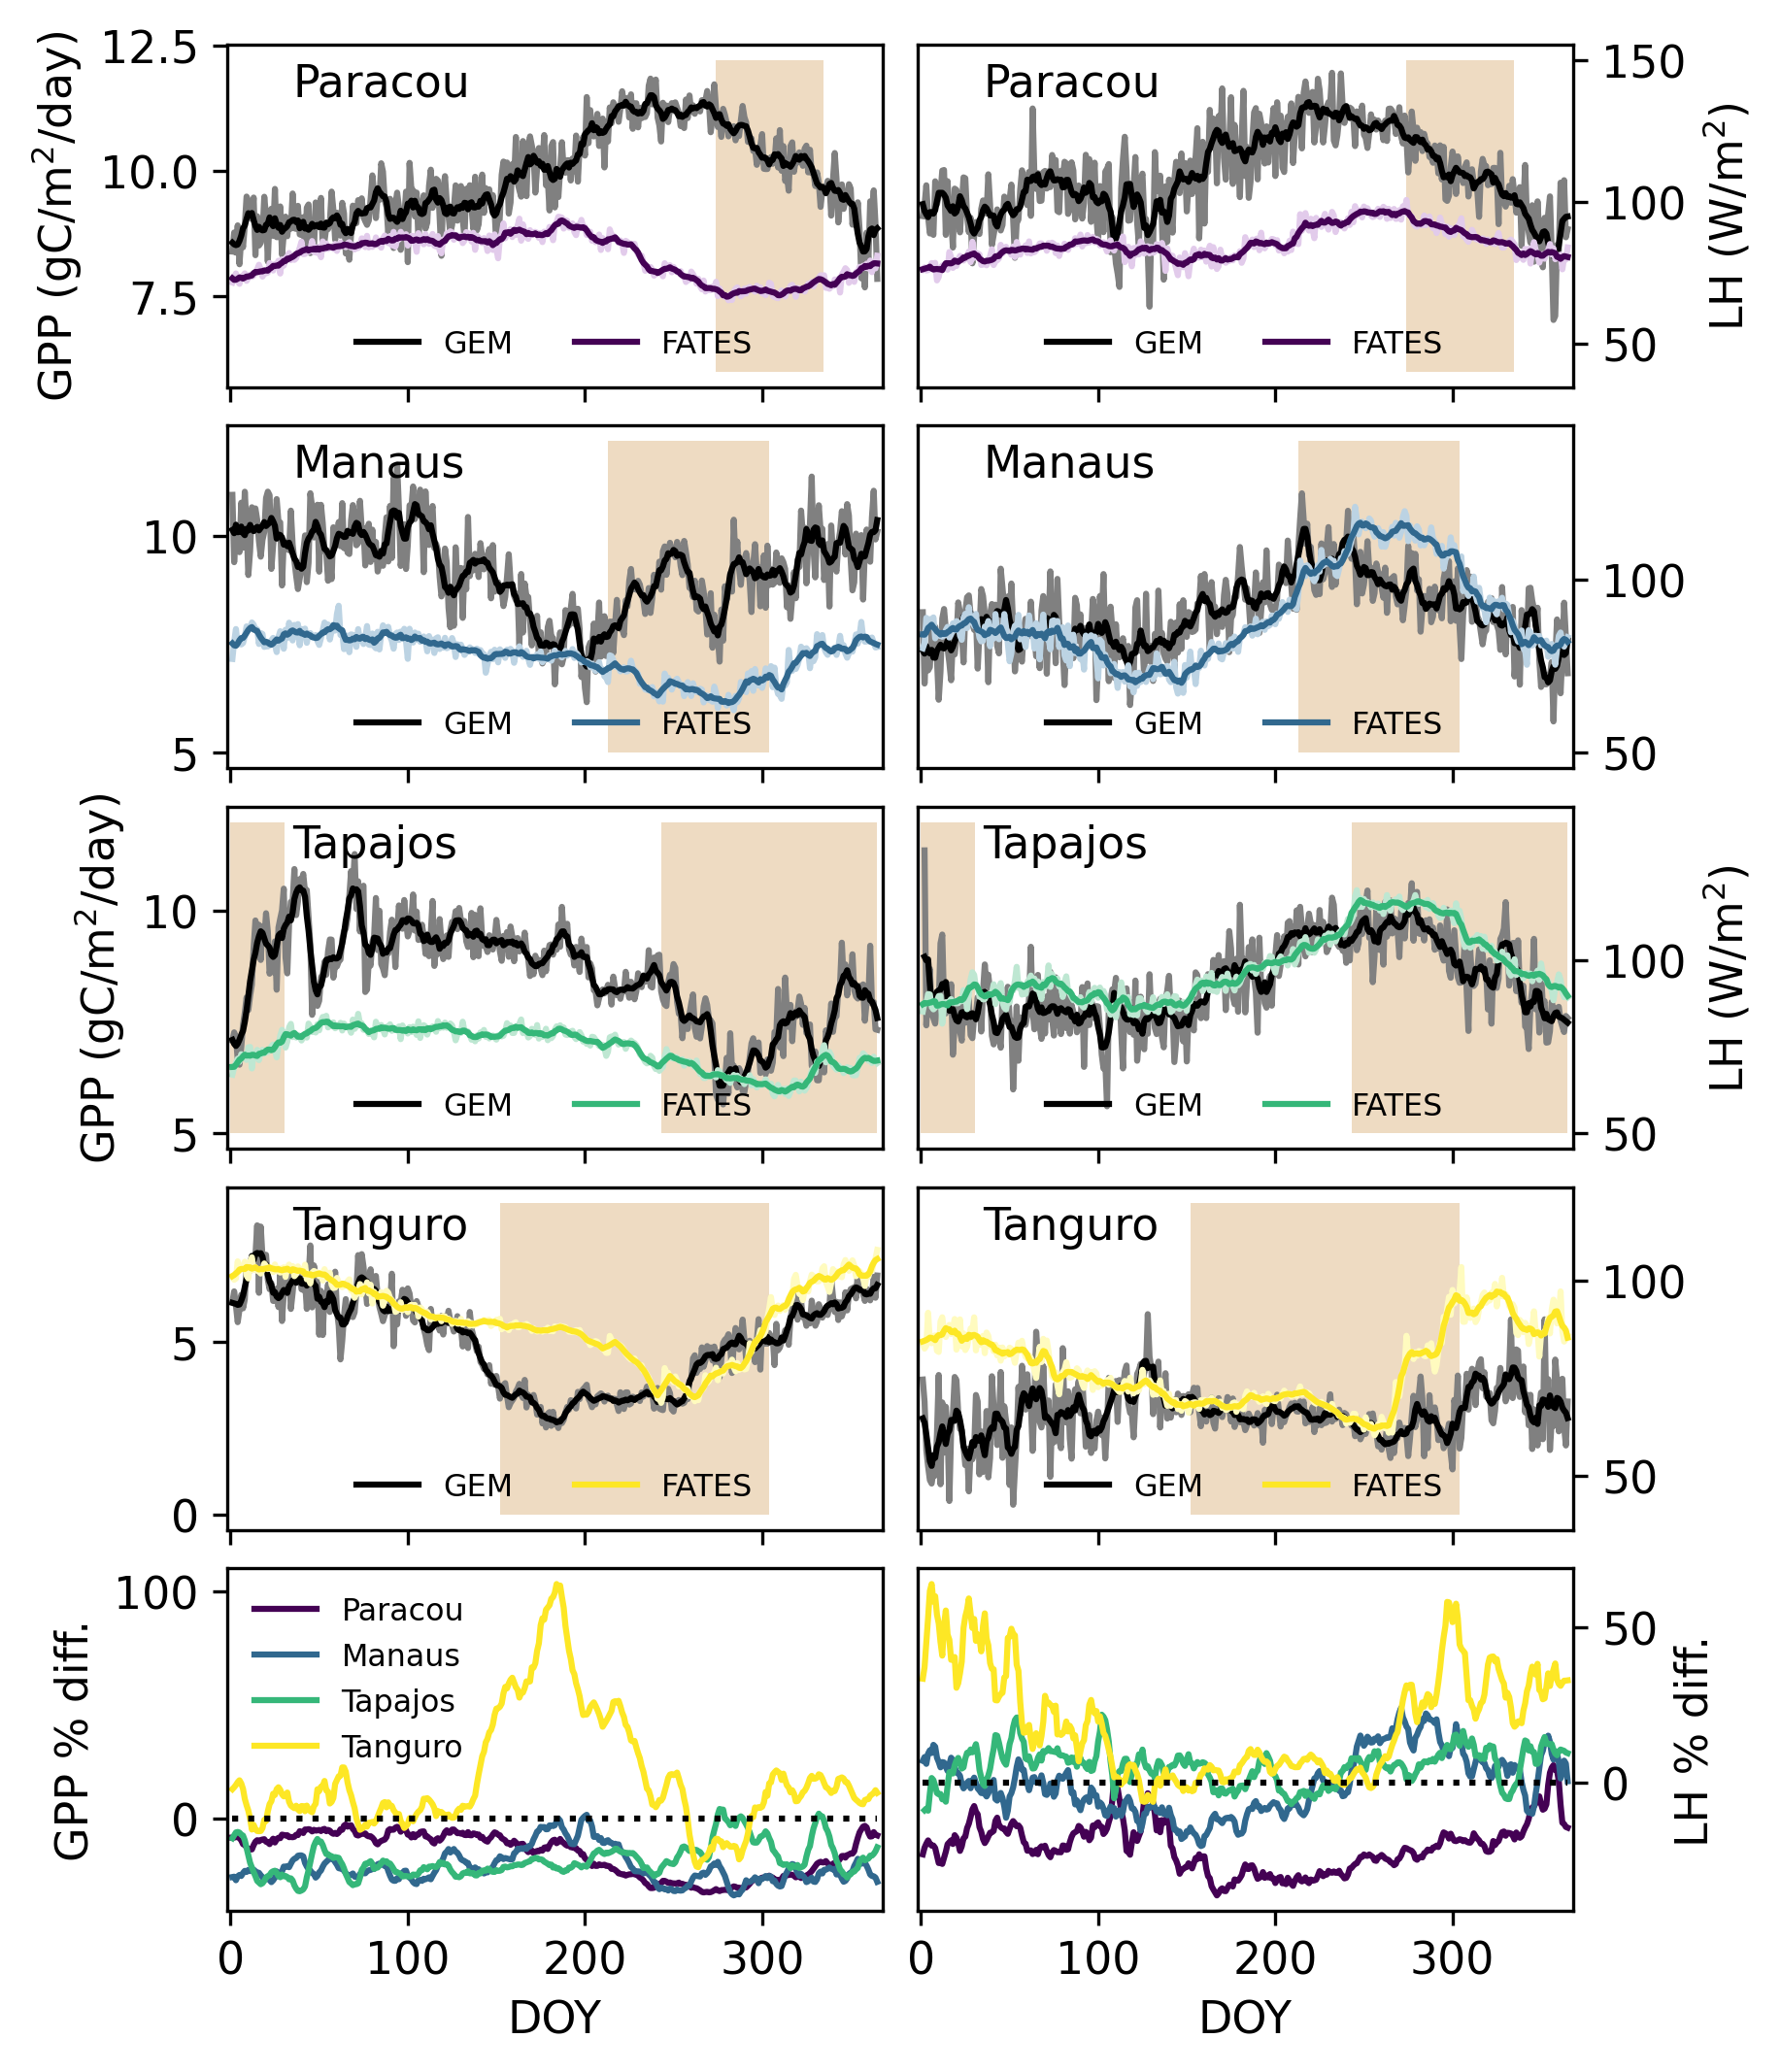

In [58]:
# Order from most to least mean annual rainfall
# add light brown bar showing dry season

fig, axes = plt.subplots(5,2, figsize=(6,7), sharex=True)

# Columns = GPP, LH
# Rows = Paracou, Manaus (K34), Tapajos, Tanguro, residuals (all)

# color scheme: observations = black
# Custom 4-color palette from Wet to Dry
# Order: Paracou (wettest) -> Manaus -> Tapajos -> Tanguro (driest)
site_colors = ['#440154', '#31688e', '#35b779', '#fde725']
shading_colors = ['#e2cbeb', '#bcd3e3', '#bee7d2', '#fffbbf']

### Row 1 - Paracou ###
# Col 1: GPP
axes[0,0].add_patch(gswp_par_dry_gpp)
axes[0,0].plot(par_jd, cf2*par_avg_GPP_R, color="grey")
axes[0,0].plot(par_jd, uniform_filter1d(cf2*par_avg_GPP_R, size=7), color="black", label="GEM")
#axes[0,0].plot(par_jd, cf2*par_avg_GPP_L, color="grey") # the two estimates of GPP are similar
#axes[0,0].plot(par_jd, uniform_filter1d(cf2*par_avg_GPP_L, size=7), color="black", label="Paracou - L")
axes[0,0].plot(fates_days, cf*fates_par_avg_GPP, color=shading_colors[0])
axes[0,0].plot(fates_days, uniform_filter1d(cf*fates_par_avg_GPP, size=7), color=site_colors[0], label="FATES")
axes[0,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[0,0].text(0.1, 0.95, 'Paracou', transform=axes[0,0].transAxes, va='top', ha='left')
axes[0,0].set_xlim(-2,368)
axes[0,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)
    
# Col 2: LH
axes[0,1].add_patch(gswp_par_dry_lh)
axes[0,1].plot(par_jd, par_avg_LH, color="grey")
axes[0,1].plot(par_jd, uniform_filter1d(par_avg_LH, size=7), color="black", label="GEM")
axes[0,1].plot(fates_days, fates_par_avg_LH, color=shading_colors[0])
axes[0,1].plot(fates_days, uniform_filter1d(fates_par_avg_LH, size=7), color=site_colors[0], label="FATES")
axes[0,1].set_ylabel('LH (W/m$^2$)')
axes[0,1].text(0.1, 0.95, 'Paracou', transform=axes[0,1].transAxes, va='top', ha='left')
axes[0,1].set_xlim(-2,368)
axes[0,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[0,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[0,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 2 - K34 Manaus ###
## col 1: GPP
axes[1,0].add_patch(gswp_k34_dry_gpp)
axes[1,0].plot(k34_jd, k34_avg_GPP, color="grey")
axes[1,0].plot(k34_jd, uniform_filter1d(k34_avg_GPP, size=7), color="black", label="GEM")
axes[1,0].plot(fates_days, cf*fates_k34_avg_GPP, color=shading_colors[1])
axes[1,0].plot(fates_days, uniform_filter1d(cf*fates_k34_avg_GPP, size=7), color=site_colors[1], label="FATES")
#axes[1,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[1,0].text(0.1, 0.95, 'Manaus', transform=axes[1,0].transAxes, va='top', ha='left')
axes[1,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## col 2: LH
axes[1,1].add_patch(gswp_k34_dry_lh)
axes[1,1].plot(k34_jd, k34_avg_LH, color="grey")
axes[1,1].plot(k34_jd, uniform_filter1d(k34_avg_LH, size=7), color="black", label="GEM")
axes[1,1].plot(fates_days, fates_k34_avg_LH, color=shading_colors[1])
axes[1,1].plot(fates_days, uniform_filter1d(fates_k34_avg_LH, size=7), color=site_colors[1], label="FATES")
#axes[1,1].set_ylabel('LH (W/m$^2$)')
axes[1,1].text(0.1, 0.95, 'Manaus', transform=axes[1,1].transAxes, va='top', ha='left')
axes[1,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[1,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[1,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 3 - Tapajos ###
## col 1: GPP
axes[2,0].add_patch(gswp_tap_dry1_gpp)
axes[2,0].add_patch(gswp_tap_dry2_gpp)
axes[2,0].plot(tap_jd, cf2*tap_avg_GPP, color="grey")
axes[2,0].plot(tap_jd, uniform_filter1d(cf2*tap_avg_GPP, size=7), color="black", label="GEM")
axes[2,0].plot(fates_days, cf*fates_tap_avg_GPP, color=shading_colors[2])
axes[2,0].plot(fates_days, uniform_filter1d(cf*fates_tap_avg_GPP, size=7), color=site_colors[2], label="FATES")
axes[2,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[2,0].text(0.1, 0.95, 'Tapajos', transform=axes[2,0].transAxes, va='top', ha='left')
axes[2,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## col 2: LH
axes[2,1].add_patch(gswp_tap_dry1_lh)
axes[2,1].add_patch(gswp_tap_dry2_lh)
axes[2,1].plot(tap_jd, tap_avg_LH, color="grey")
axes[2,1].plot(tap_jd[1:], uniform_filter1d(tap_avg_LH[1:], size=7), color="black", label="GEM")
axes[2,1].plot(fates_days, fates_tap_avg_LH, color=shading_colors[2])
axes[2,1].plot(fates_days, uniform_filter1d(fates_tap_avg_LH, size=7), color=site_colors[2], label="FATES")
axes[2,1].set_ylabel('LH (W/m$^2$)')
axes[2,1].text(0.1, 0.95, 'Tapajos', transform=axes[2,1].transAxes, va='top', ha='left')
axes[2,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[2,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[2,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

### Row 4 - Tanguro ###
## col 1: GPP
axes[3,0].add_patch(gswp_tan_dry_gpp)
axes[3,0].plot(tan_jd, tan_avg_GPP, color="grey")
axes[3,0].plot(tan_jd, uniform_filter1d(tan_avg_GPP, size=7), color="black", label="GEM")
axes[3,0].plot(fates_days, cf*fates_tan_avg_GPP, color=shading_colors[3])
axes[3,0].plot(fates_days, uniform_filter1d(cf*fates_tan_avg_GPP, size=7), color=site_colors[3], label="FATES")
#axes[3,0].set_ylabel('GPP (gC/m$^2$/day)')
axes[3,0].text(0.1, 0.95, 'Tanguro', transform=axes[3,0].transAxes, va='top', ha='left')
axes[3,0].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)
## col 2: LH
axes[3,1].add_patch(gswp_tan_dry_lh)
axes[3,1].plot(tan_jd, tan_avg_LH, color="grey")
axes[3,1].plot(tan_jd, uniform_filter1d(tan_avg_LH, size=7), color="black", label="GEM")
axes[3,1].plot(fates_days, fates_tan_avg_LH, color=shading_colors[3])
axes[3,1].plot(fates_days, uniform_filter1d(fates_tan_avg_LH, size=7), color=site_colors[3], label="FATES")
#axes[3,1].set_ylabel('LH (W/m$^2$)')
axes[3,1].text(0.1, 0.95, 'Tanguro', transform=axes[3,1].transAxes, va='top', ha='left')
axes[3,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[3,1].yaxis.set_label_position("right")  # <-- Moves label text right
axes[3,1].legend(loc='lower center',ncols=2,fontsize='x-small',frameon=False)

## row 5: residuals
## col 1: GPP
axes[4,0].plot(par_jd, uniform_filter1d(100.*(cf*fates_par_avg_GPP-cf2*par_avg_GPP_R)/(cf2*par_avg_GPP_R),size=7), color=site_colors[0],label='Paracou')
axes[4,0].plot(k34_jd, uniform_filter1d(100.*(cf*fates_k34_avg_GPP-k34_avg_GPP)/(k34_avg_GPP),size=7), color=site_colors[1],label='Manaus')
axes[4,0].plot(tap_jd, uniform_filter1d(100.*(cf*fates_tap_avg_GPP-cf2*tap_avg_GPP)/(cf2*tap_avg_GPP),size=7), color=site_colors[2],label='Tapajos')
axes[4,0].plot(tan_jd, uniform_filter1d(100.*(cf*fates_tan_avg_GPP-tan_avg_GPP)/(tan_avg_GPP),size=7), color=site_colors[3],label='Tanguro')
axes[4,0].set_ylabel('GPP % diff.')
axes[4,0].plot(par_jd, 0.*par_jd, color="black",linestyle="dotted")
axes[4,0].set_xlabel('DOY')
axes[4,0].legend(loc='upper left',fontsize='x-small',frameon=False)

## col 2: LH
axes[4,1].plot(par_jd, uniform_filter1d(100.*(fates_par_avg_LH-par_avg_LH)/par_avg_LH,size=7), color=site_colors[0])
axes[4,1].plot(k34_jd, uniform_filter1d(100.*(fates_k34_avg_LH-k34_avg_LH)/k34_avg_LH,size=7), color=site_colors[1])
axes[4,1].plot(tap_jd[1:], uniform_filter1d(100.*(fates_tap_avg_LH[1:]-tap_avg_LH[1:])/tap_avg_LH[1:],size=7), color=site_colors[2])
axes[4,1].plot(tan_jd, uniform_filter1d(100.*(fates_tan_avg_LH-tan_avg_LH)/tan_avg_LH,size=7), color=site_colors[3])
axes[4,1].set_ylabel('LH % diff.')
axes[4,1].plot(k34_jd, 0.*k34_jd, color="black",linestyle="dotted")
axes[4,1].set_xlabel('DOY')
axes[4,1].yaxis.tick_right()                 # <-- Moves ticks right
axes[4,1].yaxis.set_label_position("right")  # <-- Moves label text right


plt.tight_layout()
plt.show()

In [ ]:
# Get annual mean and std of observed and modeled GPP at each site

In [164]:
print(np.nanmean(cf2*par_avg_GPP_R),np.nanstd(cf2*par_avg_GPP_R))

9.866497568506302 0.9353724510892759


In [165]:
print(np.nanmean(cf*fates_par_avg_GPP),np.nanstd(cf*fates_par_avg_GPP))

8.263156481206513 0.4426640069850135


In [167]:
print(np.nanmean(100.*(cf*fates_par_avg_GPP-cf2*par_avg_GPP_R)/(cf2*par_avg_GPP_R)),np.nanstd(100.*(cf*fates_par_avg_GPP-cf2*par_avg_GPP_R)/(cf2*par_avg_GPP_R)))

-15.39773046482931 9.951274743589199


In [168]:
print(np.nanmean(k34_avg_GPP),np.nanstd(k34_avg_GPP))

9.207346684821424 1.0117255839917174


In [169]:
print(np.nanmean(cf*fates_k34_avg_GPP),np.nanstd(cf*fates_k34_avg_GPP))

7.213782079056167 0.49748778506539215


In [170]:
print(np.nanmean(100.*(cf*fates_k34_avg_GPP-k34_avg_GPP)/(k34_avg_GPP)))

-20.891376106352343


In [172]:
print(np.nanmean(cf2*tap_avg_GPP),np.nanstd(cf2*tap_avg_GPP))

8.519944286147974 1.145084533278087


In [173]:
print(np.nanmean(cf*fates_tap_avg_GPP),np.nanstd(cf*fates_tap_avg_GPP))

6.907675723135208 0.4643029419788162


In [176]:
print(np.nanmean(100.*(cf*fates_tap_avg_GPP[1:]-cf2*tap_avg_GPP[1:])/(cf2*tap_avg_GPP[1:])))

-17.938823518002568


In [177]:
print(np.nanmean(tan_avg_GPP),np.nanstd(tan_avg_GPP))

5.024878308032202 1.372849896865232


In [178]:
print(np.nanmean(cf*fates_tan_avg_GPP),np.nanstd(cf*fates_tan_avg_GPP))

5.710612531339854 1.1035795424572403


In [179]:
print(np.nanmean(100.*(cf*fates_tan_avg_GPP-tan_avg_GPP)/(tan_avg_GPP)))

18.71631047210754


In [198]:
# Get annual mean and std of observed and modeled LH at each site

In [199]:
print(np.nanmean(par_avg_LH),np.nanstd(par_avg_LH))

109.34422938390958 16.06324808923646


In [200]:
print(np.nanmean(fates_par_avg_LH),np.nanstd(fates_par_avg_LH))

85.33003508685387 5.7599800913289645


In [201]:
print(np.nanmean(100.*(fates_par_avg_LH-par_avg_LH)/(par_avg_LH)),np.nanstd(100.*(fates_par_avg_LH-par_avg_LH)/(par_avg_LH)))

-20.527266615097194 11.23339560756319


In [203]:
print(np.nanmean(k34_avg_LH),np.nanstd(k34_avg_LH))

90.1705419135425 11.09770905321423


In [204]:
print(np.nanmean(fates_k34_avg_LH),np.nanstd(fates_k34_avg_LH))

89.53000162203018 13.484651935583257


In [202]:
print(np.nanmean(100.*(fates_k34_avg_LH-k34_avg_LH)/k34_avg_LH))

-0.21623127943628737


In [209]:
print(np.nanmean(tap_avg_LH),np.nanstd(tap_avg_LH))

93.80666409810088 12.489166121748188


In [211]:
print(np.nanmean(fates_tap_avg_LH),np.nanstd(fates_tap_avg_LH))

97.93514577787217 10.080261069928337


In [210]:
print(np.nanmean(100.*(fates_tap_avg_LH-tap_avg_LH)/tap_avg_LH))

5.3187603292508365


In [213]:
print(np.nanmean(tan_avg_LH),np.nanstd(tan_avg_LH))

65.9506089547037 7.451575243671166


In [214]:
print(np.nanmean(fates_tan_avg_LH),np.nanstd(fates_tan_avg_LH))

77.60795665375174 9.740739634994116


In [212]:
print(np.nanmean(100.*(fates_tan_avg_LH-tan_avg_LH)/tan_avg_LH))

19.22647438691984


In [215]:
# Get fraction of early PFT basal area at each site

In [217]:
d0.FATES_BASALAREA_SZPF

<xarray.DataArray 'FATES_BASALAREA_SZPF' (time: 300, fates_levscpf: 26,
                                          lat: 23, lon: 24)>
[4305600 values with dtype=float32]
Coordinates:
  * time     (time) object 0001-02-01 00:00:00 ... 0026-01-01 00:00:00
  * lon      (lon) float32 275.0 277.5 280.0 282.5 ... 325.0 327.5 330.0 332.5
  * lat      (lat) float32 -25.58 -23.68 -21.79 -19.89 ... 12.32 14.21 16.11
Dimensions without coordinates: fates_levscpf
Attributes:
    long_name:     basal area by pft/size
    units:         m2 m-2
    cell_methods:  time: mean

In [218]:
ba_szpf=fa.scpf_to_scls_by_pft(d0.FATES_BASALAREA_SZPF,d0)

In [219]:
pft_ratio=(ba_szpf.sum(dim='fates_levscls').isel(fates_levpft=0).mean(dim="time"))/(ba_szpf.sum(dim='fates_levscls').sum(dim='fates_levpft').mean(dim="time"))


In [221]:
pft_ratio.isel(lat=par_lat_ind).isel(lon=par_lon_ind).data


array(0.1803522, dtype=float32)

In [222]:
pft_ratio.isel(lat=k34_lat_ind).isel(lon=k34_lon_ind).data


array(0.55368936, dtype=float32)

In [223]:
pft_ratio.isel(lat=tap_lat_ind).isel(lon=tap_lon_ind).data


array(0.51344395, dtype=float32)

In [224]:
pft_ratio.isel(lat=tan_lat_ind).isel(lon=tan_lon_ind).data


array(0.6461408, dtype=float32)